# Selecting 100 experimental candidates from the test run

**Layer C, not the pipeline.** `PLASMID_ANALYSIS.md` §2.3 and §76 forbid the annotation pipeline
from producing a `candidate_score` or a `top_1000`; prioritisation is a separate workflow that
consumes the finished evidence tables. This notebook is that workflow, run against the 100-plasmid
test set in `results_test/` — 92 of those plasmids carry at least one dark ORF. Nothing here writes
back into the pipeline outputs.

**What the selection rule is.** A stratified portfolio, not a score. Seven candidate classes taken
from spec §77 are filled in a fixed precedence against declared quotas, and within each class
candidates are ordered lexicographically over named fields. No weights are summed, so every
candidate traces to one rule and one ordering, and changing the rule means editing a dictionary
rather than re-tuning a coefficient.

**Ranking unit.** Dark ORF occurrences. Prevalence — how many occurrences, how many plasmids, how
many independent plasmid lineages — enters as ordering criteria rather than as a gate, and the size
of the dark family the ORF belongs to is the first ordering key throughout: a 50-member dark family
outranks a 20-member one. Membership of a wholly dark family is a preference, never a requirement.
The final 100 are de-duplicated to distinct protein sequences, because a sequence is synthesised once.

**Read this caveat before the table.** The test set is 100 plasmids. 1,946 of 2,041 dark families are
singletons, the largest has six members, and the dimensions that would normally separate candidates
— dN/dS, RNAcode, synteny, host breadth — are undefined for over 92% of families for want of members.
Section 4 quantifies this and section 9 measures how unstable the resulting list is under
subsampling. The rule is written to scale; the list it produces here is a demonstration of the rule,
not a synthesis order.

## 1. Inputs and provenance

Every table below is a pipeline output, produced by the script named in the `produced_by` column
(`workflow/rules/evidence.smk` binds each script to its output). This notebook adds no new
measurements except the opposite-strand overlap in section 3, which it computes from ORF
coordinates.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import yaml

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config" / "config.yaml").exists())
RUN = ROOT / "results_test"

# Categorical slots in fixed order, colourblind-validated; slots 1-3 are the only ones used
# together in scatter-like forms, where all pairs must separate.
C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
     "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948"}
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#8a8984", "#e4e3df", "#fcfcfb"

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "figure.facecolor": SURF, "axes.facecolor": SURF,
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8, "legend.frameon": False, "legend.fontsize": 8,
})

def clean(ax, grid_axis="y"):
    ax.grid(True, axis=grid_axis, zorder=0)
    ax.set_axisbelow(True)
    return ax

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
print("project root:", ROOT)
print("run:", RUN)

project root: /gorilla/proj/h-mel-phylo/h-mel-phylo/private/amar/plasmid_analyis
run: /gorilla/proj/h-mel-phylo/h-mel-phylo/private/amar/plasmid_analyis/results_test


In [2]:
PROVENANCE = pd.DataFrame([
    ("15_report/annotation_complete.csv",        "annotation_report.py", "ORF rows, darkness state, family id, per-ORF annotation outcome"),
    ("15_report/dark_families_complete.csv",     "annotation_report.py", "family-level evidence: structure, context, coding signal, synteny, rarity"),
    ("15_report/dark_family_rarefaction.tsv",    "rarity.py",            "dark-family discovery curve versus plasmids sampled"),
    ("14_rarity/family_rarity.tsv",              "rarity.py",            "independent lineage / MOB / host counts per family"),
    ("10_clustering/dark_families.tsv",          "protein_families.py",  "dark family membership, dark_only, percentage_dark_in_family"),
    ("10_clustering/plasmid_lineage.tsv",        "plasmid_lineage.py",   "Mash lineage cluster per plasmid, for the subsampling test"),
    ("09_quality_gate/target_eligibility.tsv",   "quality_gate.py",      "target_eligible flag and its exclusion reason"),
    ("04_orf_qc/artefact_flags.tsv",             "artefact_screen",      "AntiFam artefact flag and low-complexity fraction"),
    ("02_orf_calling/orf_index.tsv",             "orf_call / orf_index", "ORF coordinates, strand, partial, spans_origin, protein sequence"),
], columns=["file (under results_test/)", "produced_by (workflow/scripts/)", "what this notebook takes from it"])
PROVENANCE

,file (under results_test/),produced_by (workflow/scripts/),what this notebook takes from it
0,15_report/annotation_complete.csv,annotation_report.py,"ORF rows, darkness state, family id, per-ORF a..."
1,15_report/dark_families_complete.csv,annotation_report.py,"family-level evidence: structure, context, cod..."
2,15_report/dark_family_rarefaction.tsv,rarity.py,dark-family discovery curve versus plasmids sa...
3,14_rarity/family_rarity.tsv,rarity.py,independent lineage / MOB / host counts per fa...
4,10_clustering/dark_families.tsv,protein_families.py,"dark family membership, dark_only, percentage_..."
5,10_clustering/plasmid_lineage.tsv,plasmid_lineage.py,"Mash lineage cluster per plasmid, for the subs..."
6,09_quality_gate/target_eligibility.tsv,quality_gate.py,target_eligible flag and its exclusion reason
7,04_orf_qc/artefact_flags.tsv,artefact_screen,AntiFam artefact flag and low-complexity fraction
8,02_orf_calling/orf_index.tsv,orf_call / orf_index,"ORF coordinates, strand, partial, spans_origin..."


In [3]:
ann      = pd.read_csv(RUN / "15_report" / "annotation_complete.csv")
fam      = pd.read_csv(RUN / "15_report" / "dark_families_complete.csv")
darkfam  = pd.read_csv(RUN / "10_clustering" / "dark_families.tsv", sep="\t")
rarity   = pd.read_csv(RUN / "14_rarity" / "family_rarity.tsv", sep="\t")
elig     = pd.read_csv(RUN / "09_quality_gate" / "target_eligibility.tsv", sep="\t")
artefact = pd.read_csv(RUN / "04_orf_qc" / "artefact_flags.tsv", sep="\t")
orfidx   = pd.read_csv(RUN / "02_orf_calling" / "orf_index.tsv", sep="\t")
lineage  = pd.read_csv(RUN / "10_clustering" / "plasmid_lineage.tsv", sep="\t")
rarefac  = pd.read_csv(RUN / "15_report" / "dark_family_rarefaction.tsv", sep="\t")

cfg     = yaml.safe_load(open(ROOT / "config" / "config.yaml"))
targets = yaml.safe_load(open(ROOT / "config" / "test" / "targets.gpu.yaml"))

for name, df in [("annotation_complete", ann), ("dark_families_complete", fam),
                 ("dark_families", darkfam), ("orf_index", orfidx)]:
    print(f"{name:24s} {df.shape[0]:>6,} rows x {df.shape[1]:>3} columns")
print()
print(f"plasmids in run        {orfidx.plasmid_id.nunique():>6,}")
print(f"ORF occurrences        {len(orfidx):>6,}")
print(f"unique proteins        {ann.seq_id.nunique():>6,}")
print(f"dark ORF occurrences   {ann.darkness_state.notna().sum():>6,}")
print(f"dark families          {len(darkfam):>6,}")

annotation_complete       5,673 rows x  47 columns
dark_families_complete    2,041 rows x  67 columns
dark_families             2,041 rows x  12 columns
orf_index                 5,673 rows x   8 columns

plasmids in run           100
ORF occurrences         5,673
unique proteins         5,304
dark ORF occurrences    2,234
dark families           2,041


## 2. The ORF-level candidate frame

One row per dark ORF occurrence, carrying three kinds of column:

* **occurrence** — coordinates, strand, partial status, origin-spanning, protein sequence;
* **protein** — eligibility from the quality gate, artefact flags, darkness state;
* **family** — size and darkness of the dark family, and every evidence field measured on it.

Family facts are joined onto occurrences for ranking convenience only. Spec §4.3 warns against
*storing* family facts per occurrence; nothing here is written back.

In [4]:
FAM_EVIDENCE = [
    "family_id", "independent_plasmid_cluster_count", "independent_cluster_status",
    "MOB_count", "habitat_count", "host_count", "genus_count",
    "structural_match", "structural_description", "structure_evalue",
    "coding_signal", "dnds_median", "dnds_status", "under_purifying_selection",
    "rnacode_p", "rnacode_p_antisense", "rnacode_status",
    "cons_defence", "cons_integron", "cons_annotated_neighbour",
    "cons_operon_with_annotated", "cons_two_gene_operon",
    "top_hypothesis", "top_conservation", "top_q_value", "top_enrichment",
    "synteny_conservation", "neighborhood_conservation", "synteny_status", "context_recurrence",
    "rarity_labels", "evidence_dimension_count", "evidence_dimensions_present",
    "functional_hypothesis", "functional_hypothesis_support",
]
FAM_SHAPE = ["family_id", "n_members", "n_orfs", "n_plasmids", "dark_member_count",
             "annotated_member_count", "percentage_dark_in_family", "dark_only", "family_class"]

# annotation_complete.csv repeats a handful of family-level fields on every ORF row.
# Take each of them once, from the family table, so the join cannot produce _x/_y twins.
DUPLICATED_FAMILY_FIELDS = [c for c in FAM_EVIDENCE if c != "family_id" and c in ann.columns]
print("family fields taken from the family table, not from the ORF row:",
      ", ".join(DUPLICATED_FAMILY_FIELDS))

cand = (ann[ann.darkness_state.notna()]
        .drop(columns=DUPLICATED_FAMILY_FIELDS)
        .merge(elig[["seq_id", "target_eligible", "is_artefact", "exclusion_reason"]],
               on="seq_id", how="left")
        .merge(artefact[["seq_id", "low_complexity_fraction"]], on="seq_id", how="left")
        .merge(orfidx[["orf_id", "seq"]].rename(columns={"seq": "protein_sequence"}),
               on="orf_id", how="left")
        .merge(darkfam[FAM_SHAPE], on="family_id", how="left")
        .merge(fam[FAM_EVIDENCE], on="family_id", how="left"))

cand["protein_length"] = cand.protein_sequence.str.len()
cand["lineage_cluster"] = cand.plasmid_id.map(
    lineage.set_index("plasmid_id").plasmid_lineage_cluster)

assert cand.orf_id.is_unique, "one row per dark ORF occurrence"
assert cand.family_id.notna().all(), "every dark ORF must carry a family"
print(f"dark ORF occurrences      {len(cand):,}")
print(f"distinct proteins         {cand.seq_id.nunique():,}")
print(f"distinct families         {cand.family_id.nunique():,}")
print(f"plasmids carrying them    {cand.plasmid_id.nunique():,}")
print(f"plasmid lineage clusters  {cand.lineage_cluster.nunique():,}")

family fields taken from the family table, not from the ORF row: structural_match, structural_description, coding_signal, dnds_median, dnds_status, top_hypothesis, top_conservation
dark ORF occurrences      2,234
distinct proteins         2,139
distinct families         2,041
plasmids carrying them    92
plasmid lineage clusters  86


## 3. Shadow-ORF screen, computed here

Spec §9.3 asks for `opposite_strand_overlap_bp` / `_fraction` per ORF, and
`config/config.yaml` declares `qc.max_opposite_strand_overlap_fraction: 0.6` for it. In this run
those fields do not exist: `04_orf_qc/artefact_flags.tsv` carries only the AntiFam flag and the
low-complexity fraction, and `workflow/scripts/quality_gate.py` gates on AntiFam plus "the cascade
named it" and nothing else. The declared screen is therefore not applied anywhere in the pipeline
as run.

That matters more for prioritisation than for annotation. An ORF translated antisense to a real
gene passes the whole cascade cleanly — no database contains it, so it looks dark — and it is
exactly the kind of sequence one does not want on a synthesis plate. The measurement is cheap, so
the notebook makes it from the coordinates in `orf_index.tsv` and applies the project's own 0.6.

Origin-spanning ORFs are reported as `NOT_APPLICABLE` rather than 0: their interval cannot be
compared on a linear axis without the plasmid length, and spec §7.2 requires that a test which was
not applicable be distinguishable from one that returned nothing.

In [5]:
# Spec 9.3: fraction of an ORF's nucleotide span covered by ORFs on the opposite strand.
# Summed over opposite-strand neighbours and clipped at 1.0, so mutually overlapping
# antisense ORFs cannot push a fraction above one.
def opposite_strand_overlap(idx: pd.DataFrame) -> pd.DataFrame:
    out = []
    for _, g in idx.groupby("plasmid_id", sort=False):
        oid = g.orf_id.to_numpy()
        s, e = g.start.to_numpy(), g.end.to_numpy()
        strand, origin = g.strand.to_numpy(), g.spans_origin.to_numpy()
        for i in range(len(g)):
            if origin[i]:
                out.append((oid[i], np.nan, 0, "NOT_APPLICABLE"))
                continue
            other = (strand != strand[i]) & (origin == 0)
            ov = np.maximum(0, np.minimum(e[i], e[other]) - np.maximum(s[i], s[other]) + 1).sum()
            length = e[i] - s[i] + 1
            out.append((oid[i], min(ov / length, 1.0), int(ov), "MEASURED"))
    return pd.DataFrame(out, columns=["orf_id", "opposite_strand_overlap_fraction",
                                      "opposite_strand_overlap_bp", "overlap_status"])

MAX_OVERLAP = cfg["qc"]["max_opposite_strand_overlap_fraction"]
overlap = opposite_strand_overlap(orfidx)
cand = cand.merge(overlap, on="orf_id", how="left")

measured = cand[cand.overlap_status == "MEASURED"]
print(f"threshold from config/config.yaml qc.max_opposite_strand_overlap_fraction = {MAX_OVERLAP}")
print(f"dark ORFs measured                      {len(measured):,}")
print(f"  no antisense overlap at all           {(measured.opposite_strand_overlap_fraction == 0).sum():,}")
print(f"  some overlap, below threshold         {((measured.opposite_strand_overlap_fraction > 0) & (measured.opposite_strand_overlap_fraction < MAX_OVERLAP)).sum():,}")
print(f"  at or above threshold (excluded)      {(measured.opposite_strand_overlap_fraction >= MAX_OVERLAP).sum():,}")
print(f"origin-spanning, NOT_APPLICABLE         {(cand.overlap_status == 'NOT_APPLICABLE').sum():,}")

threshold from config/config.yaml qc.max_opposite_strand_overlap_fraction = 0.6
dark ORFs measured                      2,221
  no antisense overlap at all           2,138
  some overlap, below threshold         83
  at or above threshold (excluded)      0
origin-spanning, NOT_APPLICABLE         13


## 4. The eligibility gate

Hard exclusions only, every one of them a pipeline field or the screen above. Nothing biological
is excluded here: rarity, small size, absent evidence and lack of recurrence are all ranking
criteria further down, never gates, per spec §2.1.

In this run the gate removes nothing, which is itself worth stating: `dark_set.py` already builds
the dark set from `target_eligible`, AntiFam and the partial and length exclusions were applied
upstream of it, and no dark ORF here reaches the antisense-overlap threshold. The gate is kept
because it is not a no-op at corpus scale, and because a selection that assumed upstream filtering
without checking it would be trusting a fact it never verified.

In [6]:
MIN_LEN = targets.get("discovery", {}).get("min_dark_candidate_length_aa",
                                           cfg["discovery"]["min_dark_candidate_length_aa"])

gate = pd.DataFrame({
    "eligible_target":  cand.target_eligible == 1,           # quality_gate.py: not artefact, not named
    "complete_cds":     cand.partial == 0,                   # this occurrence is not edge-truncated
    "long_enough":      cand.protein_length >= MIN_LEN,      # spec 11
    "not_shadow":       (cand.overlap_status == "NOT_APPLICABLE") |
                        (cand.opposite_strand_overlap_fraction < MAX_OVERLAP),
})
cand["passes_gate"] = gate.all(axis=1)
pool = cand[cand.passes_gate].copy()

funnel = pd.Series({
    "plasmids in run":            orfidx.plasmid_id.nunique(),
    "ORF occurrences":            len(orfidx),
    "unique proteins":            ann.seq_id.nunique(),
    "dark ORF occurrences":       len(cand),
    "eligible target":            gate.eligible_target.sum(),
    "+ complete CDS":             (gate.eligible_target & gate.complete_cds).sum(),
    f"+ >= {MIN_LEN} aa":         (gate.eligible_target & gate.complete_cds & gate.long_enough).sum(),
    "+ not a shadow ORF":         cand.passes_gate.sum(),
    "distinct proteins in pool":  pool.seq_id.nunique(),
    "distinct families in pool":  pool.family_id.nunique(),
})
print(funnel.to_string())
print()
print("rows failing each condition (conditions overlap):")
print((~gate).sum().to_string())
print()
print(f"largest antisense overlap seen among dark ORFs: "
      f"{measured.opposite_strand_overlap_fraction.max():.3f} (threshold {MAX_OVERLAP})")

plasmids in run               100
ORF occurrences              5673
unique proteins              5304
dark ORF occurrences         2234
eligible target              2234
+ complete CDS               2234
+ >= 20 aa                   2234
+ not a shadow ORF           2234
distinct proteins in pool    2139
distinct families in pool    2041

rows failing each condition (conditions overlap):
eligible_target    0
complete_cds       0
long_enough        0
not_shadow         0

largest antisense overlap seen among dark ORFs: 0.495 (threshold 0.6)


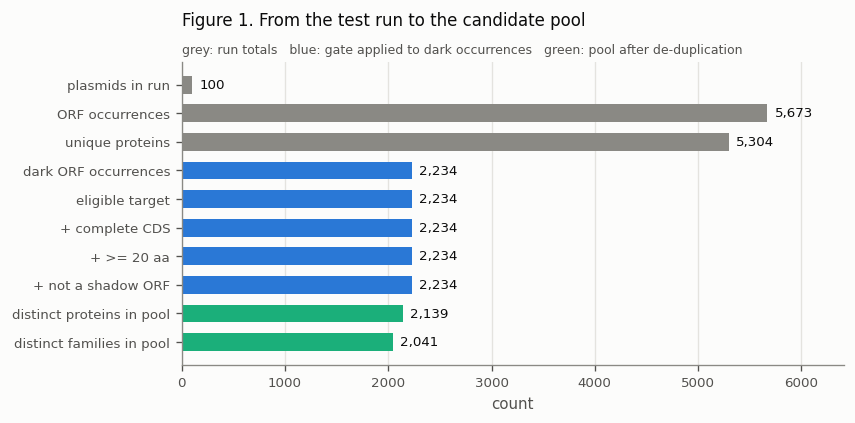

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.6))
labels = list(funnel.index)
values = funnel.values
colors = [MUTED] * 3 + [C["blue"]] * 5 + [C["aqua"]] * 2
bars = ax.barh(range(len(labels)), values, color=colors, height=0.62, zorder=2)
for i, (v, b) in enumerate(zip(values, bars)):
    ax.text(v + max(values) * 0.012, i, f"{v:,}", va="center", ha="left", fontsize=8, color=INK)
ax.set_yticks(range(len(labels)), labels)
ax.invert_yaxis()
ax.set_xlim(0, max(values) * 1.13)
ax.set_xlabel("count")
ax.set_title("Figure 1. From the test run to the candidate pool", loc="left", pad=22)
ax.text(0, 1.02, "grey: run totals   blue: gate applied to dark occurrences   green: pool after de-duplication",
        transform=ax.transAxes, va="bottom", fontsize=7.5, color=INK2)
clean(ax, grid_axis="x")
plt.tight_layout()
plt.show()

## 5. What this test run can and cannot support

Before ranking anything: which evidence dimensions actually carry a measurement here, and which are
structurally undefined because families have too few members. Spec §7.2 keeps these states apart —
`TOO_FEW_MEMBERS` is not `NO_HIT`, and neither is `NOT_RUN` — and a prioritisation that ignored the
difference would read absence of measurement as absence of evidence.

In [8]:
fp = fam.set_index("family_id")
pool_fams = fp.loc[sorted(set(pool.family_id))]

def state_counts(informative, measured_negative, too_few, unavailable):
    return {"informative": int(informative.sum()), "measured, negative": int(measured_negative.sum()),
            "too few members": int(too_few.sum()), "not available": int(unavailable.sum())}

Q_MAX = 0.05   # interpretation threshold, FDR convention (Benjamini-Hochberg q)
CONS_MIN = 0.5 # FESNov: context conservation >= 0.50 to call a family context-annotated

rows = {}
rows["structure (Foldseek)"] = state_counts(
    pool_fams.structural_match.notna(), pool_fams.structural_match.isna(),
    pd.Series(False, index=pool_fams.index), pd.Series(False, index=pool_fams.index))
rows["genomic context"] = state_counts(
    (pool_fams.top_q_value < Q_MAX) & (pool_fams.top_conservation >= CONS_MIN),
    pool_fams.top_q_value.notna() & ~((pool_fams.top_q_value < Q_MAX) & (pool_fams.top_conservation >= CONS_MIN)),
    pd.Series(False, index=pool_fams.index), pool_fams.top_q_value.isna())
rows["synteny"] = state_counts(
    (pool_fams.synteny_status == "SUCCESS") & (pool_fams.synteny_conservation >= CONS_MIN),
    (pool_fams.synteny_status == "SUCCESS") & ~(pool_fams.synteny_conservation >= CONS_MIN),
    pool_fams.synteny_status == "TOO_FEW_MEMBERS",
    ~pool_fams.synteny_status.isin(["SUCCESS", "TOO_FEW_MEMBERS"]))
rows["dN/dS"] = state_counts(
    (pool_fams.dnds_status == "MEASURED") & (pool_fams.under_purifying_selection == 1),
    (pool_fams.dnds_status == "MEASURED") & (pool_fams.under_purifying_selection != 1),
    pool_fams.dnds_status == "TOO_FEW_MEMBERS",
    pool_fams.dnds_status == "SATURATED")
rows["RNAcode"] = state_counts(
    (pool_fams.rnacode_status == "MEASURED") & (pool_fams.rnacode_p < targets["evolution"]["rnacode_max_p"]),
    (pool_fams.rnacode_status == "MEASURED") & ~(pool_fams.rnacode_p < targets["evolution"]["rnacode_max_p"]),
    pool_fams.rnacode_status == "TOO_FEW_MEMBERS",
    pd.Series(False, index=pool_fams.index))
rows["recurrence (>1 lineage)"] = state_counts(
    pool_fams.independent_plasmid_cluster_count > 1, pool_fams.independent_plasmid_cluster_count == 1,
    pd.Series(False, index=pool_fams.index), pool_fams.independent_cluster_status != "SUCCESS")
rows["host breadth"] = state_counts(
    pool_fams.host_count > 1, pool_fams.host_count == 1,
    pd.Series(False, index=pool_fams.index), pool_fams.host_count == 0)
rows["MOB breadth"] = state_counts(
    pool_fams.MOB_count > 1, pool_fams.MOB_count == 1,
    pd.Series(False, index=pool_fams.index), pool_fams.MOB_count == 0)

availability = pd.DataFrame(rows).T[["informative", "measured, negative", "too few members", "not available"]]
availability_pct = availability.div(availability.sum(axis=1), axis=0) * 100
print(f"families in the pool: {len(pool_fams):,}")
availability

families in the pool: 2,041


,informative,"measured, negative",too few members,not available
structure (Foldseek),172,1869,0,0
genomic context,61,27,0,1953
synteny,114,35,1892,0
dN/dS,9,3,2027,2
RNAcode,14,0,2027,0
recurrence (>1 lineage),56,1985,0,0
host breadth,3,780,0,1258
MOB breadth,53,1988,0,0


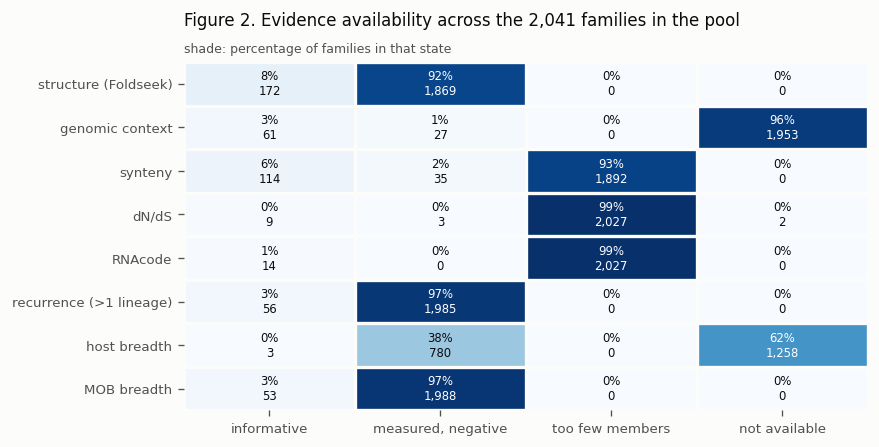

In [9]:
fig, ax = plt.subplots(figsize=(7.4, 3.8))
im = ax.imshow(availability_pct.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(availability_pct.shape[1]), availability_pct.columns, fontsize=8)
ax.set_yticks(range(availability_pct.shape[0]), availability_pct.index, fontsize=8)
for i in range(availability_pct.shape[0]):
    for j in range(availability_pct.shape[1]):
        pct = availability_pct.values[i, j]
        n = availability.values[i, j]
        ax.text(j, i, f"{pct:.0f}%\n{n:,}", ha="center", va="center", fontsize=7,
                color="#ffffff" if pct > 55 else INK)
ax.set_title(f"Figure 2. Evidence availability across the {len(pool_fams):,} families in the pool",
             loc="left", pad=22)
ax.text(0, 1.02, "shade: percentage of families in that state", transform=ax.transAxes,
        va="bottom", fontsize=7.5, color=INK2)
ax.set_xticks(np.arange(-0.5, availability_pct.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, availability_pct.shape[0], 1), minor=True)
ax.grid(which="minor", color=SURF, linewidth=2)
ax.tick_params(which="minor", length=0)
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout()
plt.show()

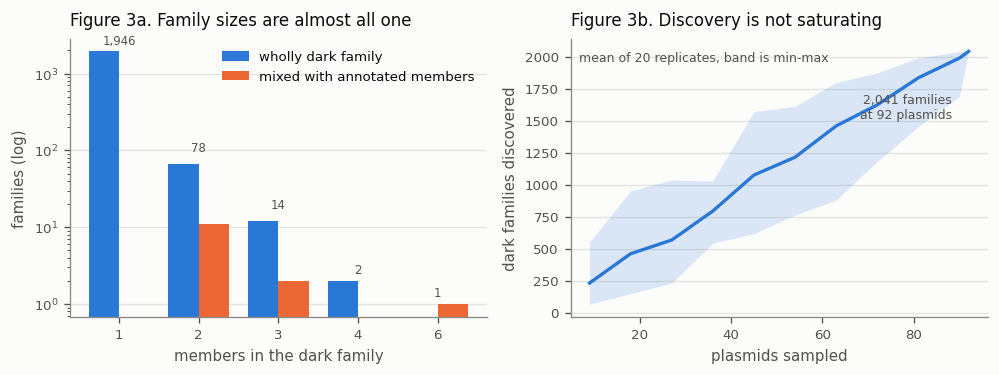

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.2))

ax = axes[0]
sizes = darkfam.groupby(["n_members", "dark_only"]).size().unstack(fill_value=0)
x = np.arange(len(sizes.index))
w = 0.38
if 1 in sizes.columns:
    ax.bar(x - w / 2, sizes[1], width=w, color=C["blue"], label="wholly dark family", zorder=2)
if 0 in sizes.columns:
    ax.bar(x + w / 2, sizes[0], width=w, color=C["orange"], label="mixed with annotated members", zorder=2)
ax.set_yscale("log")
ax.set_xticks(x, sizes.index)
ax.set_xlabel("members in the dark family")
ax.set_ylabel("families (log)")
ax.set_title("Figure 3a. Family sizes are almost all one", loc="left", pad=8)
ax.legend(loc="upper right")
clean(ax)
for xi, total in zip(x, sizes.sum(axis=1)):
    ax.text(xi, total * 1.25, f"{total:,}", ha="center", fontsize=7, color=INK2)

ax = axes[1]
ax.fill_between(rarefac.n_plasmids, rarefac.min_families, rarefac.max_families,
                color=C["blue"], alpha=0.16, linewidth=0, zorder=2)
ax.plot(rarefac.n_plasmids, rarefac.mean_families, color=C["blue"], linewidth=2, zorder=3)
ax.annotate(f"{int(rarefac.mean_families.iloc[-1]):,} families\nat {int(rarefac.n_plasmids.iloc[-1])} plasmids",
            xy=(rarefac.n_plasmids.iloc[-1], rarefac.mean_families.iloc[-1]),
            xytext=(-10, -40), textcoords="offset points", ha="right", fontsize=7.5, color=INK2)
ax.set_xlabel("plasmids sampled")
ax.set_ylabel("dark families discovered")
ax.set_title("Figure 3b. Discovery is not saturating", loc="left", pad=8)
ax.text(0.02, 0.92, f"mean of {int(rarefac.n_replicates.iloc[0])} replicates, band is min-max",
        transform=ax.transAxes, fontsize=7.5, color=INK2)
clean(ax)
plt.tight_layout()
plt.show()

## 6. Named evidence flags

Each flag is one boolean over one measurement, kept separate and never summed. Two interpretation
thresholds are declared here rather than read from config, and the distinction matters: spec §2.4
separates search thresholds from interpretation thresholds, and `config/targets.yaml` deliberately
no longer carries context cut-offs — commit `cfffef3` removed `context.min_context_conservation`,
`high_confidence_conservation`, `max_q_value` and `min_enrichment` because no code read them. They
are interpretation thresholds for this Layer C notebook, cited, and they gate nothing upstream:

* `CONS_MIN = 0.5` — FESNov (Rodríguez del Río *et al.* 2024) annotate a family from context at
  >= 50% confidence; the same value is used here for context and synteny conservation.
* `Q_MAX = 0.05` — the Benjamini-Hochberg q-value already computed by `context_features.py`, read at
  the conventional 5% false-discovery level.
* `rnacode_max_p` (0.05) and `dnds_purifying_max` (0.5) are read from `config/test/targets.gpu.yaml`,
  where the pipeline itself sets them, both cited to FESNov in `docs/PARAMETER_PROVENANCE.md`.

In [11]:
pool["ev_recurrent_lineages"] = pool.independent_plasmid_cluster_count > 1
pool["ev_recurrent_any"]      = pool.n_orfs > 1
pool["ev_defence"]            = pool.cons_defence.notna()
pool["ev_integron"]           = pool.cons_integron.notna()
pool["ev_context"]            = (pool.top_q_value < Q_MAX) & (pool.top_conservation >= CONS_MIN)
pool["ev_synteny"]            = (pool.synteny_status == "SUCCESS") & (pool.synteny_conservation >= CONS_MIN)
pool["ev_operon"]             = pool.cons_operon_with_annotated >= CONS_MIN
pool["ev_coding"]             = ((pool.rnacode_status == "MEASURED") &
                                 (pool.rnacode_p < targets["evolution"]["rnacode_max_p"])) | \
                                ((pool.dnds_status == "MEASURED") &
                                 (pool.dnds_median <= targets["evolution"]["dnds_purifying_max"]))
pool["ev_fold_known"]         = pool.darkness_state == "DARK_FOLD_KNOWN"
pool["ev_wholly_dark_family"] = (pool.dark_only == 1) & (pool.n_members > 1)

EV = [c for c in pool.columns if c.startswith("ev_")]
pool["n_signals"] = pool[EV].sum(axis=1)

by_protein = pool.drop_duplicates("seq_id")
summary = pd.DataFrame({
    "proteins carrying it": by_protein[EV].sum(),
    "families carrying it": [pool.loc[pool[c], "family_id"].nunique() for c in EV],
})
summary["% of pool proteins"] = (summary["proteins carrying it"] / len(by_protein) * 100).round(1)
print(f"pool: {len(pool):,} ORF occurrences, {len(by_protein):,} distinct proteins")
print(f"proteins with no positive signal at all: {(by_protein.n_signals == 0).sum():,} "
      f"({(by_protein.n_signals == 0).mean() * 100:.1f}%)")
summary.sort_values("proteins carrying it", ascending=False)

pool: 2,234 ORF occurrences, 2,139 distinct proteins
proteins with no positive signal at all: 1,048 (49.0%)


,proteins carrying it,families carrying it,% of pool proteins
ev_operon,854,806,39.9
ev_recurrent_any,258,160,12.1
ev_synteny,194,114,9.1
ev_fold_known,183,172,8.6
ev_wholly_dark_family,178,81,8.3
ev_recurrent_lineages,112,56,5.2
ev_context,88,61,4.1
ev_coding,44,14,2.1
ev_defence,16,16,0.7
ev_integron,1,1,0.0


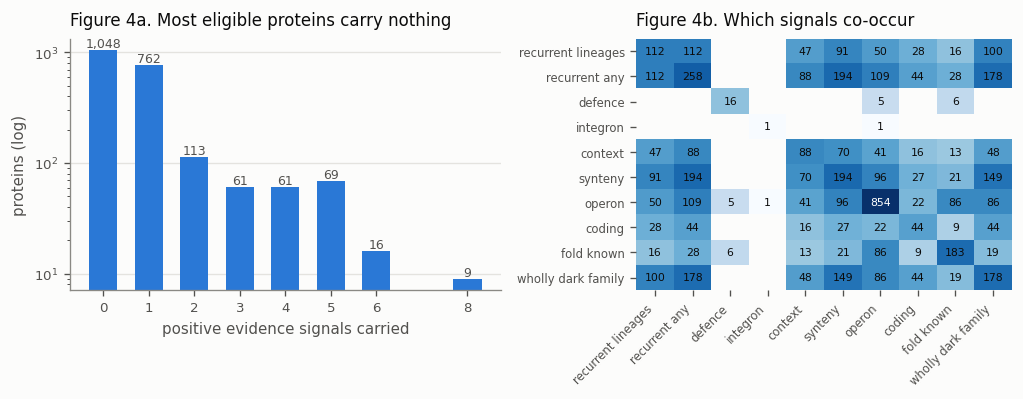

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.4), gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
counts = by_protein.n_signals.value_counts().sort_index()
ax.bar(counts.index, counts.values, color=C["blue"], width=0.62, zorder=2)
for k, v in counts.items():
    ax.text(k, v * 1.06, f"{v:,}", ha="center", fontsize=7.5, color=INK2)
ax.set_yscale("log")
ax.set_xticks(counts.index)
ax.set_xlabel("positive evidence signals carried")
ax.set_ylabel("proteins (log)")
ax.set_title("Figure 4a. Most eligible proteins carry nothing", loc="left", pad=8)
clean(ax)

ax = axes[1]
short = [c.replace("ev_", "").replace("_", " ") for c in EV]
M = np.zeros((len(EV), len(EV)), dtype=int)
for i, a in enumerate(EV):
    for j, b in enumerate(EV):
        M[i, j] = int((by_protein[a] & by_protein[b]).sum())
im = ax.imshow(np.where(M > 0, M, np.nan), cmap="Blues", aspect="auto",
               norm=mpl.colors.LogNorm(vmin=1, vmax=max(M.max(), 2)))
for i in range(len(EV)):
    for j in range(len(EV)):
        if M[i, j]:
            ax.text(j, i, M[i, j], ha="center", va="center", fontsize=6.5,
                    color="#ffffff" if M[i, j] > M.max() * 0.55 else INK)
ax.set_xticks(range(len(EV)), short, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(EV)), short, fontsize=7)
ax.set_title("Figure 4b. Which signals co-occur", loc="left", pad=8)
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout()
plt.show()

## 7. The selection rule

### 7.1 Ordering

One ordering, applied inside every class, over named fields in fixed precedence. No weights are
summed and no composite number exists, so a candidate's position is explained by reading the keys
in order.

| # | key | direction | why |
|---|-----|-----------|-----|
| 1 | `n_members` | descending | a larger dark family is a stronger observation than a smaller one |
| 2 | `dark_only` | descending | a wholly dark family beats one whose members are partly annotated |
| 3 | `independent_plasmid_cluster_count` | descending | recurrence across Mash lineages, not across clonal copies (spec §2.6) |
| 4 | `n_plasmids` | descending | distinct plasmids carrying the family |
| 5 | `n_orfs` | descending | raw occurrence count, the weakest prevalence measure |
| 6 | class key | ascending | the evidence that defines the class: context q, Foldseek E, RNAcode p |
| 7 | `evidence_dimension_count` | descending | how many named dimensions the family touches at all |
| 8 | `protein_length` | ascending | shorter sequences are cheaper to synthesise; a cost argument, not a biological one |
| 9 | `seq_id` | ascending | deterministic tiebreak, so the list is reproducible |

### 7.2 Classes and quotas

Classes come from spec §77's candidate categories. They are filled in the order listed; a protein
already taken cannot be taken again, and quota a class cannot fill cascades to the classes below
it. Both the class list and the quotas are data, edited in one place.

In [13]:
QUOTAS = {
    "recurrent across lineages": 25,
    "context-associated":        20,
    "coding signal confirmed":   10,
    "synteny-conserved":         15,
    "known fold, unknown function": 15,
    "recurrent within one lineage": 10,
    "lineage-specific orphan":    5,
}
TARGET_N = 100
assert sum(QUOTAS.values()) == TARGET_N

# predicate, class-specific ordering key (ascending, lower is better), and what the class is for.
CLASSES = {
    "recurrent across lineages": (
        lambda d: d.ev_recurrent_lineages,
        lambda d: -d.independent_plasmid_cluster_count,
        "the same dark protein in plasmids that are not clonal copies of one another"),
    "context-associated": (
        lambda d: d.ev_defence | d.ev_integron | d.ev_context,
        lambda d: d.top_q_value.fillna(1.0),
        "recurrently beside defence systems, integrons, or an enriched neighbour category"),
    "coding signal confirmed": (
        lambda d: d.ev_coding,
        lambda d: d.rnacode_p.fillna(1.0),
        "RNAcode or dN/dS says the family is translated protein-coding, not a spurious call"),
    "synteny-conserved": (
        lambda d: d.ev_synteny,
        lambda d: -d.synteny_conservation.fillna(0.0),
        "the gene order around the family is conserved across its occurrences"),
    "known fold, unknown function": (
        lambda d: d.ev_fold_known,
        lambda d: d.structure_evalue.fillna(1.0),
        "Foldseek finds a structural relative while sequence annotation found nothing"),
    "recurrent within one lineage": (
        lambda d: d.ev_recurrent_any,
        lambda d: -d.n_orfs,
        "recurs, but only inside one plasmid lineage: weaker, still better than a singleton"),
    "lineage-specific orphan": (
        lambda d: pd.Series(True, index=d.index),
        lambda d: -d.n_signals,
        "the singleton reserve: fills whatever the classes above could not"),
}

BASE_KEYS = ["n_members", "dark_only", "independent_plasmid_cluster_count", "n_plasmids", "n_orfs"]
BASE_ASC  = [False, False, False, False, False]
TAIL_KEYS = ["evidence_dimension_count", "protein_length", "seq_id"]
TAIL_ASC  = [False, True, True]

def select(frame, quotas=QUOTAS, target=TARGET_N):
    # Fill each class in turn from whatever is left, de-duplicating on protein sequence.
    # Quota a class cannot fill is carried to the classes below it, and any remainder is
    # topped up from the whole pool under the same ordering.
    taken, rows, carried = set(), [], 0
    for cls, quota in quotas.items():
        predicate, class_key, _ = CLASSES[cls]
        d = frame[predicate(frame) & ~frame.seq_id.isin(taken)].copy()
        if d.empty:
            carried += quota
            continue
        d["_class_key"] = class_key(d)
        d = (d.sort_values(BASE_KEYS + ["_class_key"] + TAIL_KEYS,
                           ascending=BASE_ASC + [True] + TAIL_ASC)
               .drop_duplicates("seq_id"))
        want = quota + carried
        chosen = d.head(want)
        carried = want - len(chosen)
        chosen = chosen.assign(selection_class=cls)
        rows.append(chosen)
        taken.update(chosen.seq_id)
    if rows:
        out = pd.concat(rows)
    else:
        out = frame.head(0).assign(selection_class=pd.Series(dtype=str))
    if len(out) < target:  # top-up under the same ordering, class-key neutral
        rest = frame[~frame.seq_id.isin(taken)].copy()
        rest["_class_key"] = -rest.n_signals
        rest = (rest.sort_values(BASE_KEYS + ["_class_key"] + TAIL_KEYS,
                                 ascending=BASE_ASC + [True] + TAIL_ASC)
                    .drop_duplicates("seq_id")
                    .head(target - len(out))
                    .assign(selection_class="top-up"))
        out = pd.concat([out, rest])
    out = out.reset_index(drop=True)
    out.insert(0, "rank", np.arange(1, len(out) + 1))
    return out

selected = select(pool)
print(f"selected {len(selected)} candidates, {selected.seq_id.nunique()} distinct proteins, "
      f"{selected.family_id.nunique()} distinct families")
per_family = selected.family_id.value_counts()
print(f"families contributing more than one candidate: {(per_family > 1).sum()} "
      f"(largest contributes {per_family.max()})")
print("This follows directly from ordering key 1: members of the largest dark families sort to the")
print("top of every class, so a family with several members can occupy several slots. Adding")
print('"family_id" to the drop_duplicates call in select() makes the list one-per-family instead.')
print()
print(selected.selection_class.value_counts().reindex(list(QUOTAS) + ["top-up"]).dropna().to_string())

selected 100 candidates, 100 distinct proteins, 49 distinct families
families contributing more than one candidate: 35 (largest contributes 4)
This follows directly from ordering key 1: members of the largest dark families sort to the
top of every class, so a family with several members can occupy several slots. Adding
"family_id" to the drop_duplicates call in select() makes the list one-per-family instead.

selection_class
recurrent across lineages       25.0
context-associated              20.0
coding signal confirmed         10.0
synteny-conserved               15.0
known fold, unknown function    15.0
recurrent within one lineage    10.0
lineage-specific orphan          5.0


In [14]:
SHOW = ["rank", "selection_class", "seq_id", "plasmid_id", "orf_id", "protein_length",
        "n_members", "dark_only", "independent_plasmid_cluster_count", "n_plasmids", "n_orfs",
        "n_signals", "darkness_state", "structural_description", "top_hypothesis",
        "rarity_labels", "evidence_dimensions_present"]
view = selected[SHOW].copy()
view["seq_id"] = view.seq_id.str.slice(0, 12)
view["structural_description"] = view.structural_description.fillna("").str.slice(0, 40)
with pd.option_context("display.max_rows", 120, "display.max_colwidth", 42):
    display(view)

,rank,selection_class,seq_id,plasmid_id,orf_id,protein_length,n_members,dark_only,independent_plasmid_cluster_count,n_plasmids,n_orfs,n_signals,darkness_state,structural_description,top_hypothesis,rarity_labels,evidence_dimensions_present
0,1,recurrent across lineages,023036dc948b,IMGPR_plasmid_3300028378_000042,IMGPR_plasmid_3300028378_000042|7,169,6,0,5,5,6,2,DARK_NO_STRUCTURE,,NaN,CROSS_MOB,"EVOLUTIONARY_CONSERVATION,DISTRIBUTION"
1,2,recurrent across lineages,7f9a83349157,IMGPR_plasmid_2713897047_000002,IMGPR_plasmid_2713897047_000002|112,91,4,1,4,4,4,5,DARK_NO_STRUCTURE,,eggnog_description:Member of a two-com...,CROSS_MOB,"GENOMIC_CONTEXT,EVOLUTIONARY_CONSERVAT..."
2,3,recurrent across lineages,215666de3fde,GenBank_CP080224.1,GenBank_CP080224.1|120,116,4,1,4,4,4,5,DARK_NO_STRUCTURE,,eggnog_description:Member of a two-com...,CROSS_MOB,"GENOMIC_CONTEXT,EVOLUTIONARY_CONSERVAT..."
3,4,recurrent across lineages,4d979e8fc955,GenBank_CP129609.1,GenBank_CP129609.1|148,116,4,1,4,4,4,5,DARK_NO_STRUCTURE,,eggnog_description:Member of a two-com...,CROSS_MOB,"GENOMIC_CONTEXT,EVOLUTIONARY_CONSERVAT..."
4,5,recurrent across lineages,903016b9a1ee,IMGPR_plasmid_2718218494_000001,IMGPR_plasmid_2718218494_000001|20,119,4,1,4,4,4,5,DARK_NO_STRUCTURE,,eggnog_description:Member of a two-com...,CROSS_MOB,"GENOMIC_CONTEXT,EVOLUTIONARY_CONSERVAT..."
5,6,recurrent across lineages,d95fe1ab12f1,IMGPR_plasmid_2871735898_000001,IMGPR_plasmid_2871735898_000001|93,77,3,1,3,4,4,8,DARK_FOLD_KNOWN,2hjj-assembly1_A Solution NMR structure,eggnog_description:Plasmid SOS inhibit...,"RARE,CROSS_MOB","GENOMIC_CONTEXT,EVOLUTIONARY_CONSERVAT..."
6,7,recurrent across lineages,11f3128e9e13,IMGPR_plasmid_2718218494_000001,IMGPR_plasmid_2718218494_000001|79,80,3,1,3,4,4,8,DARK_FOLD_KNOWN,2hjj-assembly1_A Solution NMR structure,eggnog_description:Plasmid SOS inhibit...,"RARE,CROSS_MOB","GENOMIC_CONTEXT,EVOLUTIONARY_CONSERVAT..."
7,8,recurrent across lineages,f4aa8c0f910c,IMGPR_plasmid_2695420545_000001,IMGPR_plasmid_2695420545_000001|74,80,3,1,3,4,4,8,DARK_FOLD_KNOWN,2hjj-assembly1_A Solution NMR structure,eggnog_description:Plasmid SOS inhibit...,"RARE,CROSS_MOB","GENOMIC_CONTEXT,EVOLUTIONARY_CONSERVAT..."
8,9,recurrent across lineages,029eecd4a4be,GenBank_CP129609.1,GenBank_CP129609.1|156,146,3,1,3,3,3,8,DARK_FOLD_KNOWN,6wis-assembly2_B Copper resistance prote,cog_id:COG3696,"RARE,CROSS_MOB","GENOMIC_CONTEXT,EVOLUTIONARY_CONSERVAT..."
9,10,recurrent across lineages,e974626e3fa0,GenBank_CP080224.1,GenBank_CP080224.1|128,146,3,1,3,3,3,8,DARK_FOLD_KNOWN,6wis-assembly2_B Copper resistance prote,cog_id:COG3696,"RARE,CROSS_MOB","GENOMIC_CONTEXT,EVOLUTIONARY_CONSERVAT..."


## 8. What the 100 are made of

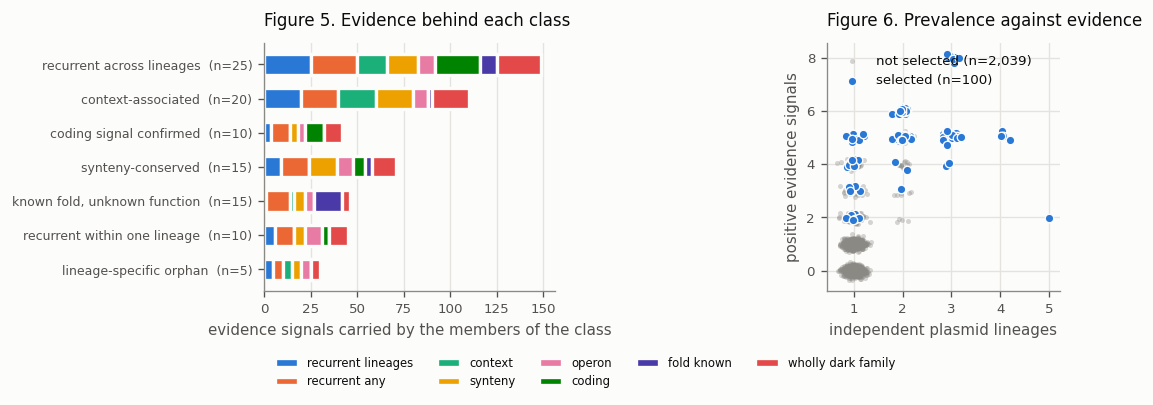

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6), gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
comp = (selected.groupby("selection_class")[EV].sum()
        .reindex([c for c in list(QUOTAS) + ["top-up"] if c in set(selected.selection_class)]))
order = [c for c in EV if comp[c].sum() > 0]
bottom = np.zeros(len(comp))
slots = [C["blue"], C["orange"], C["aqua"], C["yellow"], C["magenta"], C["green"], C["violet"], C["red"]]
for k, c in enumerate(order):
    vals = comp[c].values
    ax.barh(range(len(comp)), vals, left=bottom, height=0.62, color=slots[k % 8],
            label=c.replace("ev_", "").replace("_", " "), zorder=2, edgecolor=SURF, linewidth=2)
    bottom += vals
ax.set_yticks(range(len(comp)), [f"{i}  (n={int((selected.selection_class == i).sum())})" for i in comp.index],
              fontsize=7.5)
ax.invert_yaxis()
ax.set_xlabel("evidence signals carried by the members of the class")
ax.set_title("Figure 5. Evidence behind each class", loc="left", pad=10)
ax.legend(ncol=5, loc="upper left", bbox_to_anchor=(0, -0.22), fontsize=7)
clean(ax, grid_axis="x")

ax = axes[1]
rest = pool.drop_duplicates("seq_id")
rest = rest[~rest.seq_id.isin(selected.seq_id)]
jitter_rng = np.random.default_rng(cfg["seed"])
jit = lambda n, s=0.10: jitter_rng.normal(0, s, n)
ax.scatter(rest.independent_plasmid_cluster_count + jit(len(rest)),
           rest.n_signals + jit(len(rest)), s=9, color=MUTED, alpha=0.35, linewidth=0,
           label=f"not selected (n={len(rest):,})", zorder=2)
ax.scatter(selected.independent_plasmid_cluster_count + jit(len(selected)),
           selected.n_signals + jit(len(selected)), s=26, color=C["blue"], linewidth=0.8,
           edgecolor=SURF, label=f"selected (n={len(selected)})", zorder=3)
ax.set_xlabel("independent plasmid lineages")
ax.set_ylabel("positive evidence signals")
ax.set_title("Figure 6. Prevalence against evidence", loc="left", pad=10)
ax.legend(loc="upper left")
clean(ax, grid_axis="both")
plt.tight_layout()
plt.show()

## 9. How stable is this list?

With 1,946 of 2,041 families seen once, most of the prevalence signal rests on single observations,
and a single observation is the least stable thing in the dataset. The test: draw half the plasmids,
recompute the prevalence fields from that draw alone, re-run the identical selection, and count how
many of the original 100 come back.

**What this measures and what it does not.** Only the prevalence fields are recomputed — occurrences,
distinct plasmids, independent lineages, family size within the draw. Context, synteny, coding
signal and structure are kept as the full run measured them, because recomputing those means
re-running MacSyFinder, RNAcode and Foldseek. Persistence here is therefore an optimistic bound:
the real instability of a half-size run is at least this large.

In [16]:
def resample_prevalence(sub):
    # Recompute every prevalence field from the subsample alone, then rebuild the flags
    # that depend on them. Intrinsic family evidence is carried over unchanged.
    g = sub.groupby("family_id")
    sub = sub.copy()
    sub["n_orfs"] = sub.family_id.map(g.orf_id.nunique())
    sub["n_plasmids"] = sub.family_id.map(g.plasmid_id.nunique())
    sub["n_members"] = sub.family_id.map(g.seq_id.nunique())
    sub["independent_plasmid_cluster_count"] = sub.family_id.map(g.lineage_cluster.nunique())
    sub["ev_recurrent_lineages"] = sub.independent_plasmid_cluster_count > 1
    sub["ev_recurrent_any"] = sub.n_orfs > 1
    sub["ev_wholly_dark_family"] = (sub.dark_only == 1) & (sub.n_members > 1)
    sub["n_signals"] = sub[EV].sum(axis=1)
    return sub

N_REPLICATES = targets["rarity"]["rarefaction_replicates"]   # 20, the same count the pipeline uses
rng = np.random.default_rng(cfg["seed"])
plasmids = np.array(sorted(pool.plasmid_id.unique()))
hits = pd.Series(0, index=selected.seq_id)

for _ in range(N_REPLICATES):
    keep = rng.choice(plasmids, size=len(plasmids) // 2, replace=False)
    sub = resample_prevalence(pool[pool.plasmid_id.isin(keep)])
    replicate = select(sub)
    hits.loc[hits.index.isin(replicate.seq_id)] += 1

persistence = hits / N_REPLICATES
selected["persistence"] = selected.seq_id.map(persistence)
print(f"{N_REPLICATES} replicates at {len(plasmids) // 2} of {len(plasmids)} plasmids")
print(f"median persistence   {persistence.median():.2f}")
print(f"returned every time  {(persistence == 1).sum():>3} of {len(persistence)}")
print(f"returned never       {(persistence == 0).sum():>3} of {len(persistence)}")
print()
print(selected.groupby("selection_class").persistence.agg(["size", "median"]).round(2).to_string())

20 replicates at 46 of 92 plasmids
median persistence   0.45
returned every time    0 of 100
returned never         7 of 100

                              size  median
selection_class                           
coding signal confirmed         10    0.55
context-associated              20    0.35
known fold, unknown function    15    0.50
lineage-specific orphan          5    0.30
recurrent across lineages       25    0.45
recurrent within one lineage    10    0.28
synteny-conserved               15    0.60


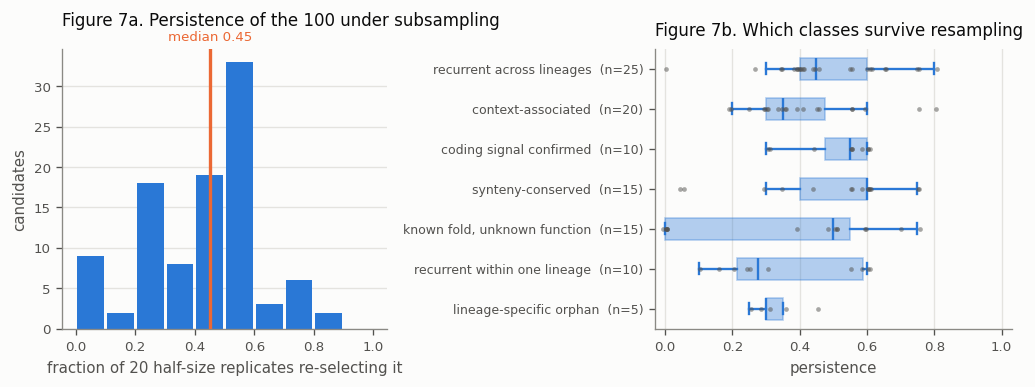

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.3), gridspec_kw={"width_ratios": [1, 1.1]})

ax = axes[0]
ax.hist(persistence, bins=np.linspace(0, 1, 11), color=C["blue"], zorder=2, rwidth=0.9)
ax.axvline(persistence.median(), color=C["orange"], linewidth=2, zorder=3)
ax.text(persistence.median(), ax.get_ylim()[1] * 1.02, f"median {persistence.median():.2f}",
        color=C["orange"], fontsize=8, ha="center", va="bottom")
ax.set_xlabel(f"fraction of {N_REPLICATES} half-size replicates re-selecting it")
ax.set_ylabel("candidates")
ax.set_title("Figure 7a. Persistence of the 100 under subsampling", loc="left", pad=14)
clean(ax)

ax = axes[1]
classes = [c for c in list(QUOTAS) + ["top-up"] if c in set(selected.selection_class)]
data = [selected.loc[selected.selection_class == c, "persistence"].values for c in classes]
bp = ax.boxplot(data, vert=False, widths=0.55, patch_artist=True, showfliers=False)
for patch in bp["boxes"]:
    patch.set_facecolor(C["blue"])
    patch.set_alpha(0.35)
    patch.set_edgecolor(C["blue"])
for el in ["whiskers", "caps", "medians"]:
    for line in bp[el]:
        line.set_color(C["blue"])
        line.set_linewidth(1.4)
for i, c in enumerate(classes, start=1):
    vals = selected.loc[selected.selection_class == c, "persistence"]
    ax.scatter(vals + np.random.default_rng(1).normal(0, 0.012, len(vals)),
               np.full(len(vals), i), s=8, color=INK2, alpha=0.5, linewidth=0, zorder=3)
ax.set_yticks(range(1, len(classes) + 1), [f"{c}  (n={len(d)})" for c, d in zip(classes, data)], fontsize=7.5)
ax.invert_yaxis()
ax.set_xlabel("persistence")
ax.set_xlim(-0.03, 1.03)
ax.set_title("Figure 7b. Which classes survive resampling", loc="left", pad=8)
clean(ax, grid_axis="x")
plt.tight_layout()
plt.show()

## 10. Reading this list

**What a row is.** One dark ORF occurrence, standing for one protein sequence, admitted by the
first class whose rule it satisfied, ordered within that class by the keys in §7.1. `persistence`
says how often the same protein returns when half the plasmids are removed.

**What the list is not.** It is not a ranking of biological importance. No column of this notebook
enters the pipeline tables, and nothing here re-labels a dark protein as functional: a
context-associated candidate remains `DARK` with a hypothesis attached, per spec §2.7 and §57.

**What this run cannot tell you.** At 92 plasmids the evidence that normally separates candidates is
mostly undefined — dN/dS and RNAcode need three members and a family has one, synteny needs repeated
occurrences, host and MOB breadth need metadata that is absent for a large share of families
(Figure 2). Family size, the first ordering key, spans 1 to 6 here, so it barely orders anything;
at corpus scale, where families reach the hundreds, it will dominate the list as intended. The
rarefaction curve (Figure 3b) is still climbing at the last sampled point, so the families that
would populate a real top 100 are mostly not in this run at all.

**What to change when this is run against the full corpus.**

1. Re-read `QUOTAS`. They are sized for a pool where only 315 families carry any positive signal.
   With a corpus-scale pool the classes will compete, and the split between recurrence, context and
   structure becomes a scientific decision rather than an availability constraint.
2. Decide whether one family may supply several candidates. Here it can, and does — ordering by
   family size first means the members of the largest dark families fill the upper ranks together.
   That is reasonable when families are small and homology within them is remote, and it becomes
   wasteful at corpus scale, where a single family can hold hundreds of members; `select()` takes
   one edit to enforce one candidate per family.
3. Expect the singleton reserve to disappear. It exists here because the informative classes cannot
   fill their quotas.
4. Re-run §9 with the full replicate machinery. Half-corpus resampling will exercise context and
   coding evidence too, which this version holds fixed.
5. Add the properties dimension when it exists. Spec §56.1 names `PROTEIN_PROPERTIES` as an evidence
   dimension, and no stage in this run produces it, so membrane association, cysteine content and
   low-complexity structure play no part in the ordering above. For candidates destined for
   expression in *E. coli* that is a real omission.

**One pipeline defect this notebook had to work around.** The opposite-strand overlap screen of
spec §9.3 is declared in `config/config.yaml` and computed nowhere, so §3 computes it here. It
belongs in `04_orf_qc`, where `quality_gate.py` could use it. The ORF identifiers in
`02_orf_calling/orf_index.tsv` are also ordinals (`<plasmid>|<n>`) rather than the
`<plasmid_id>:<start>-<end>:<strand>` form that spec §5.2 requires, which is noted here and not
acted on.